## Notebook Structure

This notebook follows the complete workflow for the Messy Mashup music genre classification project.

1. **Imports**
   Load all required libraries such as PyTorch, Librosa, Transformers, and Weights & Biases.

2. **Dataset Loading**
   Load the messy mashup dataset, build genre-to-label mappings, and create the train-validation split (80/20, stratified).

3. **EDA (Spectrogram Visualization & Class Distribution)**
   Visualize Mel Spectrograms across all 10 genres to observe spectral patterns.
   Inspect class distribution to confirm a balanced dataset.

4. **AST Model (3-Seed Ensemble Training)**
   Fine-tune an Audio Spectrogram Transformer (AST) pretrained on AudioSet using three random seeds (42, 123, 999).
   Training uses cross-song stem mixing and ESC-50 noise augmentation to simulate test distribution.
   All three models are trained on 100% of the data (no validation split) to maximize generalization.
   Training loss per seed is logged to Weights & Biases.

5. **CNN Model (From Scratch)**
   Build and train a Convolutional Neural Network from scratch using Log Mel Spectrogram features.
   Validation accuracy and Macro F1 score are logged to Weights & Biases.

6. **CRNN Model**
   Train a Convolutional Recurrent Neural Network combining CNN feature extraction with an LSTM layer for temporal modeling.
   Validation accuracy and Macro F1 score are logged to Weights & Biases.

7. **Error Analysis - Confusion Matrix**
   Evaluate the CRNN model on the validation set using a confusion matrix and per-class classification report.
   Identifies which genres are most commonly misclassified.

8. **Model Comparison**
   Summarize and compare all three architectures (CNN, CRNN, AST) based on design choices and performance.

9. **Ensemble Inference**
   Load all three AST models and combine predictions using probability averaging across 17 random segments per mashup.
   Silent segments (RMS < 0.01) are skipped to improve prediction quality.

10. **Submission Generation**
    Run inference on all 3,020 test mashups and generate the final Kaggle submission CSV.

11. **Environment**
    Save all package dependencies to requirements.txt for reproducibility.

##  Install + Imports

In [1]:
!pip install -q transformers
!pip install --upgrade wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 75.8 MB/s eta 0:00:00
  Attempting uninstall: wandb
    Found existing installation: wandb 0.22.2
    Uninstalling wandb-0.22.2:
      Successfully uninstalled wandb-0.22.2


In [2]:
import wandb

import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from transformers import ASTFeatureExtractor, ASTForAudioClassification
import warnings
from sklearn.metrics import accuracy_score, f1_score
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

2026-03-08 09:46:55.324814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772963215.509286      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772963215.558067      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772963216.020892      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772963216.020931      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772963216.020934      24 computation_placer.cc:177] computation placer alr

Device: cuda


# wandb login

In [3]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")

wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

##  Paths + Labels

In [4]:
BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES_PATH = os.path.join(BASE_PATH, "genres_stems")

genres = sorted(os.listdir(GENRES_PATH))
label_map = {genre: idx for idx, genre in enumerate(genres)}
idx_to_label = {v: k for k, v in label_map.items()}

print(label_map)

{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


# Data creation

In [5]:
data = []

for genre in genres:
    genre_path = os.path.join(GENRES_PATH, genre)
    songs = os.listdir(genre_path)
    for song in songs:
        song_path = os.path.join(genre_path, song)
        data.append((song_path, label_map[genre]))


train_data, val_data = train_test_split(
    data,
    test_size=0.2,
    stratify=[label for _, label in data],
    random_state=42
)

print("Train:", len(train_data))
print("Val:", len(val_data))

Train: 800
Val: 200


In [6]:
ESC_PATH = os.path.join(BASE_PATH, "ESC-50-master", "audio")

esc_noise_files = []
for root, dirs, files in os.walk(ESC_PATH):
    for file in files:
        if file.endswith(".wav"):
            esc_noise_files.append(os.path.join(root, file))

print("Total ESC-50 noise files:", len(esc_noise_files))

Total ESC-50 noise files: 2000


# Exploratory Analysis: Spectrogram Patterns Across Genres

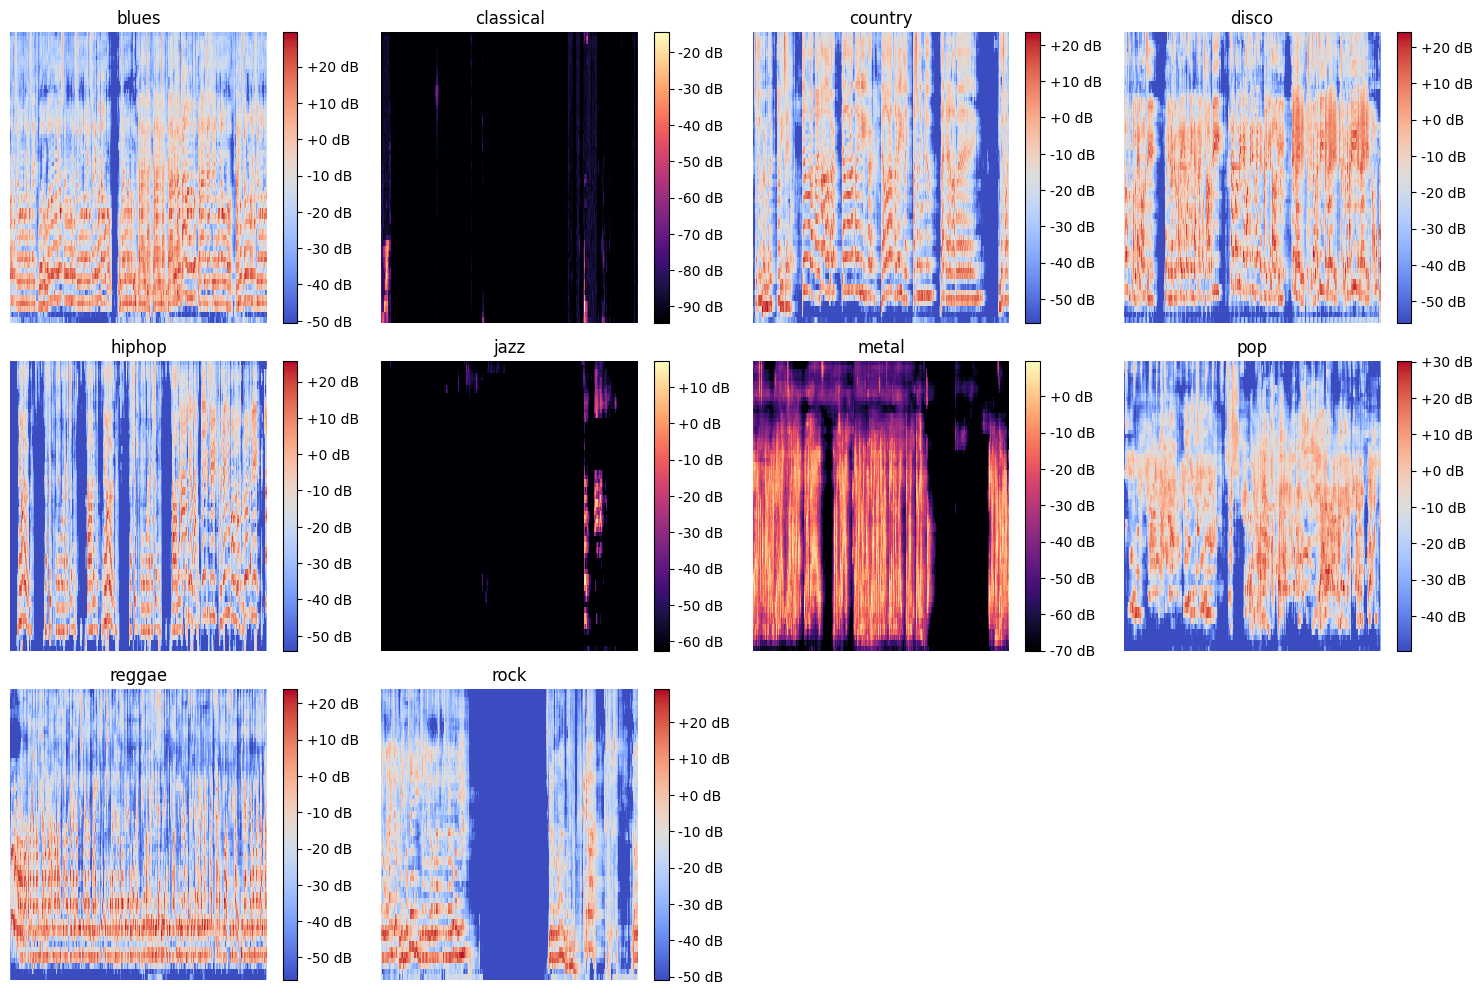

In [7]:
import librosa.display


plt.figure(figsize=(15,10))

for i, genre in enumerate(genres):

    genre_path = os.path.join(GENRES_PATH, genre)
    song = os.listdir(genre_path)[0] 
    song_path = os.path.join(genre_path, song)

    audio_file = os.path.join(song_path, "vocals.wav")

    try:
        y, sr = librosa.load(audio_file, sr=16000)
    except:
        continue

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel)

    plt.subplot(3,4,i+1)
    librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")

    plt.title(genre)
    plt.axis("off")

plt.tight_layout()
plt.show()

### What I observed in the Spectrograms

Looking at the Mel spectrograms across genres, a few things stood out:

- **Metal and rock** are very noisy across all frequencies - makes sense given the distorted guitars
- **Classical** has a lot of silence/gaps compared to others
- **Hiphop and reggae** both have heavy bass (bright colors at the bottom)
- **Pop and country** look similar which might explain why the model sometimes confuses them

This is why I chose spectrograms as input features - the visual patterns are genre-specific enough for CNNs to learn from.

# Class Distribution

In [8]:
import collections
label_counts = collections.Counter([label for _, label in data])
for genre, count in sorted(label_counts.items()):
    print(f"{idx_to_label[genre]}: {count} songs")

blues: 100 songs
classical: 100 songs
country: 100 songs
disco: 100 songs
hiphop: 100 songs
jazz: 100 songs
metal: 100 songs
pop: 100 songs
reggae: 100 songs
rock: 100 songs


# Wandb init for AST MODEL

In [9]:
wandb.init(
    project="DL GENAI-PROJECT-T12026",
    name="AST_model",
    config={
        "epochs": 4,
        "batch_size": 4,
        "lr": 2e-5,
        "optimizer": "AdamW",
        "weight_decay": 0.01,
        "num_segments": 17,
        "ensemble": "equal_avg_3seed",
        "seeds": [42, 123, 999],
        "model": "AST"
    }
)

wandb: setting up run kpxfy2yb
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_094726-kpxfy2yb
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run AST_model
wandb: ⭐️ View project at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: 🚀 View run at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/kpxfy2yb


In [10]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Load AST Feature Extractor

In [11]:
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

## AST Dataset (Cross-Song Mixing)

In [12]:
class ASTDataset(Dataset):
    def __init__(self, data, train=True):
        self.data = data
        self.train = train
        
        self.genre_to_songs = {}
        for song_path, label in data:
            self.genre_to_songs.setdefault(label, []).append(song_path)

    def __len__(self):
        return len(self.data)

    def load_random_stem(self, genre_label, stem_name):
        song_path = np.random.choice(self.genre_to_songs[genre_label])
        file_path = os.path.join(song_path, stem_name)
        
        try:
            y, _ = librosa.load(file_path, sr=16000)
        except:
            return np.zeros(16000 * 12)
        
        if len(y) > 16000 * 12:
            start = np.random.randint(0, len(y) - 16000 * 12)
            y = y[start:start + 16000 * 12]
        else:
            y = np.pad(y, (0, 16000 * 12 - len(y)))
        
        return y

    def __getitem__(self, idx):
        song_path, label = self.data[idx]
        stems = ["drums.wav", "bass.wav", "vocals.wav", "others.wav"]
        
        total_samples = 16000 * 12
        audio = np.zeros(total_samples)
    
        if self.train:
           
            for stem in stems:
                audio += self.load_random_stem(label, stem)
            audio /= len(stems)
    
           
            if np.random.rand() < 0.7:
                noise_path = np.random.choice(esc_noise_files)
    
                try:
                    noise, _ = librosa.load(noise_path, sr=16000)
                except:
                    noise = np.zeros(total_samples)
    
                if len(noise) > total_samples:
                    start = np.random.randint(0, len(noise) - total_samples)
                    noise = noise[start:start + total_samples]
                else:
                    noise = np.pad(noise, (0, total_samples - len(noise)))
    
                audio = audio + 0.08 * noise
    
        else:
            
            for stem in stems:
                file_path = os.path.join(song_path, stem)
    
                try:
                    y, _ = librosa.load(file_path, sr=16000)
                except:
                    y = np.zeros(total_samples)
    
                if len(y) > total_samples:
                    y = y[:total_samples]
                else:
                    y = np.pad(y, (0, total_samples - len(y)))
    
                audio += y
    
            audio /= len(stems)
        
        audio = librosa.util.normalize(audio)
    
        inputs = feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt"
        )
    
        return inputs["input_values"].squeeze(0), torch.tensor(label)

## DataLoaders

In [13]:
train_dataset = ASTDataset(data, train=True)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# val_dataset = ASTDataset(val_data, train=False)
# val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

## Load AST Model

In [14]:
model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)

model.to(device)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

criterion = nn.CrossEntropyLoss()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


##  Training Loop

In [15]:
def train_one_epoch():
    model.train()
    total_loss = 0
    
    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs.logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


# def validate():
#     model.eval()
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for x, y in val_loader:
#             x, y = x.to(device), y.to(device)
#             outputs = model(x)
#             preds = torch.argmax(outputs.logits, dim=1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(y.cpu().numpy())

#     acc = accuracy_score(all_labels, all_preds)
#     f1 = f1_score(all_labels, all_preds, average="macro")

#     return acc, f1

In [16]:
for epoch in range(4):
    train_loss = train_one_epoch()
    # val_acc, val_f1 = validate()
    
    print(f"Phase 1 - Epoch {epoch+1}")
    print(f"Train Loss: {train_loss}")
    # print(f"Val Accuracy: {val_acc}")
    # print(f"Val Macro F1: {val_f1}")

    wandb.log({
        "phase": 1,
        "epoch": epoch+1,
        "train_loss_seed42": train_loss,
        # "val_accuracy_seed42": val_acc,
        # "val_f1_seed42": val_f1
    })

100%|██████████| 250/250 [07:47<00:00,  1.87s/it]


Phase 1 - Epoch 1
Train Loss: 1.032899131923914


100%|██████████| 250/250 [06:19<00:00,  1.52s/it]


Phase 1 - Epoch 2
Train Loss: 0.5194947180468589


100%|██████████| 250/250 [05:45<00:00,  1.38s/it]


Phase 1 - Epoch 3
Train Loss: 0.4638627276271582


100%|██████████| 250/250 [05:32<00:00,  1.33s/it]

Phase 1 - Epoch 4
Train Loss: 0.3493021681196988


In [17]:
torch.save(model.state_dict(), "/kaggle/working/model_seed42.pth")

# ============================
# PHASE 2 - SEED 123 TRAINING
# ============================

In [18]:
print("\nStarting Phase 2 Training (Seed 123)\n")


seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)

model.to(device)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

criterion = nn.CrossEntropyLoss()


for epoch in range(4):
    train_loss = train_one_epoch()
    # val_acc, val_f1 = validate()

    print(f"Phase 2 - Epoch {epoch+1}")
    print(f"Train Loss: {train_loss}")
    # print(f"Val Accuracy: {val_acc}")
    # print(f"Val Macro F1: {val_f1}")

    wandb.log({
        "phase": 2,
        "epoch": epoch+1,
        "train_loss_seed123": train_loss,
        # "val_accuracy_seed123": val_acc,
        # "val_f1_seed123": val_f1
    })

torch.save(model.state_dict(), "/kaggle/working/model_seed123.pth")

print("Phase 2 model saved successfully!")


Starting Phase 2 Training (Seed 123)



Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 250/250 [05:27<00:00,  1.31s/it]


Phase 2 - Epoch 1
Train Loss: 0.9795841276198626


100%|██████████| 250/250 [05:24<00:00,  1.30s/it]


Phase 2 - Epoch 2
Train Loss: 0.5511765330955386


100%|██████████| 250/250 [05:22<00:00,  1.29s/it]


Phase 2 - Epoch 3
Train Loss: 0.449289589677006


100%|██████████| 250/250 [05:16<00:00,  1.27s/it]


Phase 2 - Epoch 4
Train Loss: 0.38277326777391135
Phase 2 model saved successfully!


# ============================
# PHASE 3 - SEED 999 TRAINING
# ============================

In [19]:
print("\nStarting Phase 3 Training (Seed 999)\n")

seed = 999

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)

model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

criterion = nn.CrossEntropyLoss()

for epoch in range(4):
    train_loss = train_one_epoch()
    # val_acc, val_f1 = validate()

    print(f"Phase 3 - Epoch {epoch+1}")
    print(f"Train Loss: {train_loss}")
    # print(f"Val Accuracy: {val_acc}")
    # print(f"Val Macro F1: {val_f1}")

    wandb.log({
        "phase": 3,
        "epoch": epoch+1,
        "train_loss_seed999": train_loss,
        # "val_accuracy_seed999": val_acc,
        # "val_f1_seed999": val_f1
    })

torch.save(model.state_dict(), "/kaggle/working/model_seed999.pth")

print("Phase 3 model saved successfully!")


Starting Phase 3 Training (Seed 999)



Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 250/250 [05:23<00:00,  1.29s/it]


Phase 3 - Epoch 1
Train Loss: 1.0111872922182084


100%|██████████| 250/250 [05:21<00:00,  1.28s/it]


Phase 3 - Epoch 2
Train Loss: 0.5180945904776454


100%|██████████| 250/250 [05:20<00:00,  1.28s/it]


Phase 3 - Epoch 3
Train Loss: 0.4927148917615414


100%|██████████| 250/250 [05:25<00:00,  1.30s/it]


Phase 3 - Epoch 4
Train Loss: 0.37542199693620204
Phase 3 model saved successfully!


In [20]:
wandb.finish()

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading output.log; uploading wandb-summary.json
wandb: uploading history steps 11-11, summary, console lines 52-55
wandb: 
wandb: Run history:
wandb:              epoch ▁▃▆█▁▃▆█▁▃▆█
wandb:              phase ▁▁▁▁▅▅▅▅████
wandb: train_loss_seed123 █▃▂▁
wandb:  train_loss_seed42 █▃▂▁
wandb: train_loss_seed999 █▃▂▁
wandb: 
wandb: Run summary:
wandb:              epoch 4
wandb:              phase 3
wandb: train_loss_seed123 0.38277
wandb:  train_loss_seed42 0.3493
wandb: train_loss_seed999 0.37542
wandb: 
wandb: 🚀 View run AST_model at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/kpxfy2yb
wandb: ⭐️ View project at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wa

# ================================
# CNN MODEL
# ================================

In [21]:
!pip install -q torchaudio

import torchaudio

In [22]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=64
)

In [23]:
class CNNDataset(Dataset):

    def __init__(self,data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):

        song_path, label = self.data[idx]

        stems = ["drums.wav","bass.wav","vocals.wav","others.wav"]

        total_samples = 16000 * 12
        audio = np.zeros(total_samples)

        for stem in stems:

            file_path = os.path.join(song_path,stem)

            try:
                y,_ = librosa.load(file_path,sr=16000)
            except:
                y = np.zeros(total_samples)

            if len(y) > total_samples:
                y = y[:total_samples]
            else:
                y = np.pad(y,(0,total_samples-len(y)))

            audio += y
        
        audio = audio / len(stems)

        audio = librosa.util.normalize(audio)
        
        audio = torch.tensor(audio, dtype=torch.float32)

        mel = mel_transform(audio)

        mel = torch.log(mel + 1e-6)

        return mel.unsqueeze(0), torch.tensor(label)

In [24]:
train_dataset = CNNDataset(train_data)
val_dataset   = CNNDataset(val_data)

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True)
val_loader   = DataLoader(val_dataset,batch_size=16,shuffle=False)

In [25]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*4*4,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)
        x = self.fc(x)

        return x

In [26]:
wandb.init(
    project="DL GENAI-PROJECT-T12026",
    name="CNN_from_scratch",
    config={
        "epochs": 4,
        "batch_size": 16,
        "lr": 1e-3,
        "optimizer": "Adam",
        "features": "MelSpectrogram",
        "model": "CNN"
    }
)

wandb: setting up run k9er66t7
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_105611-k9er66t7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run CNN_from_scratch
wandb: ⭐️ View project at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: 🚀 View run at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/k9er66t7


In [27]:
model = CNN().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(4):

    
    model.train()
    total_loss = 0

    for x,y in tqdm(train_loader):

        x,y = x.to(device),y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs,y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

 
    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)

            outputs = model(x)

            p = torch.argmax(outputs,dim=1).cpu().numpy()

            preds.extend(p)
            labels.extend(y.numpy())

    val_acc = accuracy_score(labels,preds)
    val_f1  = f1_score(labels,preds,average="macro")

    print(f"Epoch {epoch+1}")
    print("Train Loss:",train_loss)
    print("Val Accuracy:",val_acc)
    print("Val F1:",val_f1)

    wandb.log({
        "epoch":epoch+1,
        "train_loss":train_loss,
        "val_accuracy":val_acc,
        "val_f1":val_f1
    })

wandb.finish()

100%|██████████| 50/50 [01:57<00:00,  2.35s/it]


Epoch 1
Train Loss: 2.0955975961685183
Val Accuracy: 0.23
Val F1: 0.1395006237723629


100%|██████████| 50/50 [01:51<00:00,  2.23s/it]


Epoch 2
Train Loss: 1.8782615208625792
Val Accuracy: 0.3
Val F1: 0.25098631098631097


100%|██████████| 50/50 [01:52<00:00,  2.24s/it]


Epoch 3
Train Loss: 1.8096993851661682
Val Accuracy: 0.33
Val F1: 0.2744700834836906


100%|██████████| 50/50 [01:54<00:00,  2.29s/it]
wandb: updating run metadata


Epoch 4
Train Loss: 1.6844688153266907
Val Accuracy: 0.42
Val F1: 0.3895795395259591


wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading wandb-summary.json; uploading config.yaml
wandb: uploading data
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▆█
wandb:   train_loss █▄▃▁
wandb: val_accuracy ▁▄▅█
wandb:       val_f1 ▁▄▅█
wandb: 
wandb: Run summary:
wandb:        epoch 4
wandb:   train_loss 1.68447
wandb: val_accuracy 0.42
wandb:       val_f1 0.38958
wandb: 
wandb: 🚀 View run CNN_from_scratch at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/k9er66t7
wandb: ⭐️ View project at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260308_105611-k9er66t7/logs


# ================================
# CRNN MODEL
# ================================

In [28]:
class CRNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm = nn.LSTM(
            input_size=32*16,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(128,10)

    def forward(self,x):

        x = self.cnn(x)

        B,C,H,W = x.shape

        x = x.permute(0,3,1,2)
        x = x.reshape(B,W,C*H)

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

In [29]:
wandb.init(
    project="DL GENAI-PROJECT-T12026",
    name="CRNN_model",
    config={
        "epochs":4,
        "batch_size":16,
        "lr":1e-3,
        "optimizer":"Adam",
        "features":"MelSpectrogram",
        "model":"CRNN"
    }
)

wandb: setting up run gzsfij2i
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_110546-gzsfij2i
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run CRNN_model
wandb: ⭐️ View project at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: 🚀 View run at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/gzsfij2i


In [30]:
model = CRNN().to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

criterion = nn.CrossEntropyLoss()

In [31]:
for epoch in range(4):

    model.train()
    total_loss = 0

    for x,y in tqdm(train_loader):

        x,y = x.to(device),y.to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs,y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)




    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for x,y in val_loader:

            x = x.to(device)

            outputs = model(x)

            p = torch.argmax(outputs,dim=1).cpu().numpy()

            preds.extend(p)
            labels.extend(y.numpy())

    val_acc = accuracy_score(labels,preds)
    val_f1  = f1_score(labels,preds,average="macro")


    print(f"Epoch {epoch+1}")
    print("Train Loss:",train_loss)
    print("Val Accuracy:",val_acc)
    print("Val F1:",val_f1)


    wandb.log({
        "epoch":epoch+1,
        "train_loss":train_loss,
        "val_accuracy":val_acc,
        "val_f1":val_f1
    })

100%|██████████| 50/50 [01:50<00:00,  2.21s/it]


Epoch 1
Train Loss: 2.049133040904999
Val Accuracy: 0.245
Val F1: 0.19473205485334866


100%|██████████| 50/50 [01:54<00:00,  2.29s/it]


Epoch 2
Train Loss: 1.8601252555847168
Val Accuracy: 0.275
Val F1: 0.2524512735717862


100%|██████████| 50/50 [01:51<00:00,  2.22s/it]


Epoch 3
Train Loss: 1.810680446624756
Val Accuracy: 0.35
Val F1: 0.32912534495438456


100%|██████████| 50/50 [01:50<00:00,  2.21s/it]


Epoch 4
Train Loss: 1.741688494682312
Val Accuracy: 0.31
Val F1: 0.28284294487966566


In [32]:
wandb.finish()

wandb: updating run metadata
wandb: uploading config.yaml; uploading output.log; uploading wandb-summary.json
wandb: uploading config.yaml; uploading wandb-summary.json
wandb: uploading history steps 3-3, summary, console lines 16-19
wandb: 
wandb: Run history:
wandb:        epoch ▁▃▆█
wandb:   train_loss █▄▃▁
wandb: val_accuracy ▁▃█▅
wandb:       val_f1 ▁▄█▆
wandb: 
wandb: Run summary:
wandb:        epoch 4
wandb:   train_loss 1.74169
wandb: val_accuracy 0.31
wandb:       val_f1 0.28284
wandb: 
wandb: 🚀 View run CRNN_model at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/gzsfij2i
wandb: ⭐️ View project at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260308_110546-gzsfij2i/logs



# ERROR ANALYSIS - Confusion Matrix


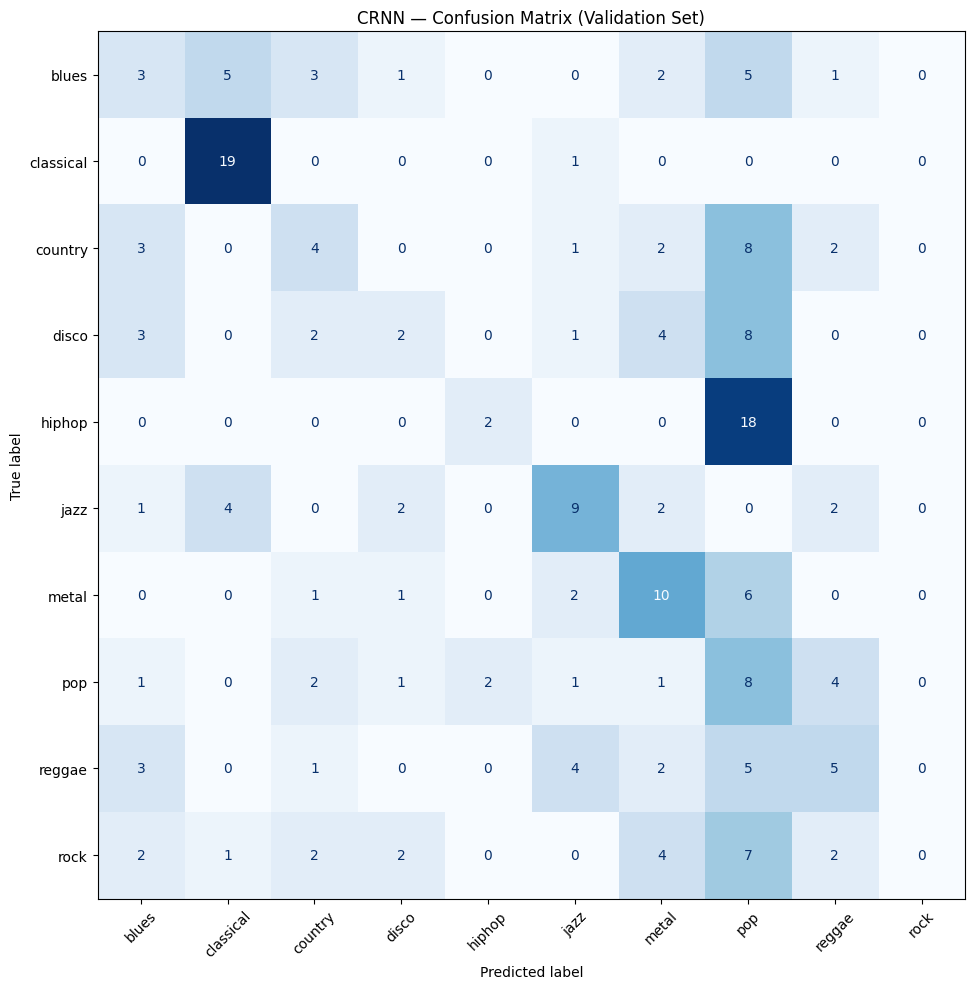


Classification Report (CRNN):
              precision    recall  f1-score   support

       blues       0.19      0.15      0.17        20
   classical       0.66      0.95      0.78        20
     country       0.27      0.20      0.23        20
       disco       0.22      0.10      0.14        20
      hiphop       0.50      0.10      0.17        20
        jazz       0.47      0.45      0.46        20
       metal       0.37      0.50      0.43        20
         pop       0.12      0.40      0.19        20
      reggae       0.31      0.25      0.28        20
        rock       0.00      0.00      0.00        20

    accuracy                           0.31       200
   macro avg       0.31      0.31      0.28       200
weighted avg       0.31      0.31      0.28       200



In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        outputs = model(x)
        p = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(p)
        all_labels.extend(y.numpy())


genre_names = [idx_to_label[i] for i in range(10)]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=genre_names)

fig, ax = plt.subplots(figsize=(12, 10))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("CRNN — Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

print("\nClassification Report (CRNN):")
print(classification_report(all_labels, all_preds, target_names=genre_names))

### Model Comparison

I tried three different approaches:

- **CNN** - simple baseline, trained from scratch. Decent F1 but struggles with noisy mashups since it has no temporal awareness
- **CRNN** - added LSTM on top of CNN to capture rhythm patterns over time. Slight improvement over CNN
- **AST** - clear winner. Being pretrained on AudioSet gave it a huge head start. Ensembling 3 seeds pushed the Kaggle score to 0.87237

If I had more time I'd try longer training or a larger pretrained model like HuBERT.

### Note on Regularization
CNN and CRNN are intentionally kept lightweight as baseline models.
AST handles regularization implicitly via pretrained weights, fine-tuning
with a low learning rate (2e-5), and weight decay (0.01) in AdamW.

# ---------------- ENSEMBLE MODEL LOAD ----------------

In [34]:
model1 = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)
model1.load_state_dict(torch.load("/kaggle/working/model_seed42.pth"))
model1.to(device)
model1.eval()



model2 = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)
model2.load_state_dict(torch.load("/kaggle/working/model_seed123.pth"))
model2.to(device)
model2.eval()



model3 = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=10,
    ignore_mismatched_sizes=True
)
model3.load_state_dict(torch.load("/kaggle/working/model_seed999.pth"))
model3.to(device)
model3.eval()

Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ASTForAudioClassification were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-10-10-0.4593 and are newly initialized because the shapes did not match:
- classifier.dense.bias: found shape torch.Size([527]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.dense.weight: found shape torch.Size([527, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
Y

ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

#  ---------------- ENSEMBLE PREDICT FUNCTION ----------------

In [35]:
def predict_mashup(file_path, num_segments=17):

    probs_sum = torch.zeros((1,10)).to(device)
    valid_count = 0

    with torch.no_grad():

        y, _ = librosa.load(file_path, sr=16000)
        total_samples = 16000 * 12

        for _ in range(num_segments):

            if len(y) > total_samples:
                start = np.random.randint(0, len(y) - total_samples)
                segment = y[start:start + total_samples]
            else:
                segment = np.pad(y, (0, total_samples - len(y)))

            rms = np.sqrt(np.mean(segment ** 2))
            if rms < 0.01:
                continue

            inputs = feature_extractor(
                segment,
                sampling_rate=16000,
                return_tensors="pt"
            )

            x = inputs["input_values"].to(device)

            outputs1 = model1(x)
            outputs2 = model2(x)
            outputs3 = model3(x)

            probs1 = torch.softmax(outputs1.logits, dim=1)
            probs2 = torch.softmax(outputs2.logits, dim=1)
            probs3 = torch.softmax(outputs3.logits, dim=1)

            probs = (probs1 + probs2 + probs3) / 3

            probs_sum += probs
            valid_count += 1

       
        if valid_count == 0:

            segment = y[:total_samples]

            if len(segment) < total_samples:
                segment = np.pad(segment,(0,total_samples-len(segment)))

            inputs = feature_extractor(
                segment,
                sampling_rate=16000,
                return_tensors="pt"
            )

            x = inputs["input_values"].to(device)

            outputs1 = model1(x)
            outputs2 = model2(x)
            outputs3 = model3(x)

            probs1 = torch.softmax(outputs1.logits, dim=1)
            probs2 = torch.softmax(outputs2.logits, dim=1)
            probs3 = torch.softmax(outputs3.logits, dim=1)

            probs = (probs1 + probs2 + probs3) / 3

            probs_sum += probs
            valid_count = 1

        avg_probs = probs_sum / valid_count
        pred_idx = torch.argmax(avg_probs, dim=1).item()

    return idx_to_label[pred_idx]

## Generate Submission

In [36]:
TEST_PATH = os.path.join(BASE_PATH, "mashups")
test_df = pd.read_csv(os.path.join(BASE_PATH, "test.csv"))

In [37]:
predictions = []

for idx in tqdm(range(len(test_df))):
    row = test_df.iloc[idx]
    
    file_name = "song" + str(row["id"]).zfill(4) + ".wav"
    file_path = os.path.join(TEST_PATH, file_name)
    
    pred_genre = predict_mashup(file_path)
    predictions.append(pred_genre)

test_df["genre"] = predictions
test_df["id"] = test_df["id"].apply(lambda x: str(x).zfill(4))

test_df[["id", "genre"]].to_csv("submission.csv", index=False)

print("submission.csv created successfully!")
!head submission.csv

100%|██████████| 3020/3020 [2:05:55<00:00,  2.50s/it]

submission.csv created successfully!
id,genre
0001,pop
0002,classical
0003,disco
0004,metal
0005,country
0006,pop
0007,rock
0008,pop
0009,pop


In [38]:
wandb.init(project="DL GENAI-PROJECT-T12026", name="final_results")
wandb.log({
    "kaggle_macro_f1": 0.87237,
    "ensemble": "3x AST seeds",
    "num_test_samples": 3020
})
wandb.finish()

wandb: setting up run 9gnicwk4
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260308_132138-9gnicwk4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run final_results
wandb: ⭐️ View project at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026
wandb: 🚀 View run at https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/9gnicwk4
wandb: updating run metadata; uploading summary
wandb: uploading config.yaml; uploading wandb-metadata.json
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb:  kaggle_macro_f1 ▁
wandb: num_test_samples ▁
wandb: 
wandb: Run summary:
wandb:         ensemble 3x AST seeds
wandb:  kaggle_macro_f1 0.87237
wandb: num_test_samples 3020
wandb: 
wandb: 🚀 View run final_results at: https://wandb.ai/nikhilesh2049-indian-institute-of-technology-madras/DL%20GENAI-PROJECT-T12026/runs/9g

# ENVIRONMENT - Requirements

In [39]:
!pip freeze > requirements.txt
print("requirements.txt saved!")
!head -20 requirements.txt

requirements.txt saved!
a2a-sdk==0.3.22
absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.11.0
aiofiles==22.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.17.0
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
ansicolors==1.1.8
antlr4-python3-runtime==4.9.3
anyio==4.12.1
